# 06 - Interpretabilidad del modelo con SHAP

XGBoost es una caja negra, predice pero no explica.
SHAP nos permite entender por qué el modelo tomó cada decisión,
tanto a nivel global (todo el dataset) como local (un asteroide específico).

## 1. Carga del modelo y los datos

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

modelo = joblib.load('../data/xgboost_final.pkl')

print("Modelo y datos cargados")
print(f"X_test: {X_test.shape}")

Modelo y datos cargados
X_test: (4526, 4)


## 2. Cálculo de SHAP values

TreeExplainer es el explicador específico para modelos basados 
en árboles como XGBoost. Es más rápido y preciso que el 
explicador genérico porque aprovecha la estructura del árbol
para calcular los SHAP values exactos.

In [2]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculados")
print(f"Shape de shap_values: {shap_values.shape}")

SHAP values calculados
Shape de shap_values: (4526, 4)


## 3. Summary Plot — importancia global de features

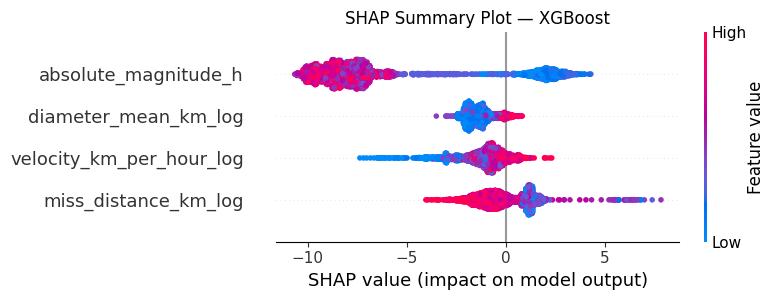

In [3]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — XGBoost')
plt.tight_layout()
plt.show()

In [4]:
y_pred = modelo.predict(X_test)

# Falsos negativos: era peligroso pero el modelo dijo no peligroso
falsos_negativos = X_test[(y_test.values == True) & (y_pred == False)]

print(f"Total falsos negativos: {len(falsos_negativos)}")
print(falsos_negativos.head())

Total falsos negativos: 61
     absolute_magnitude_h  diameter_mean_km_log  velocity_km_per_hour_log  \
289             -1.383661              1.092359                  0.168951   
330             -1.418868              1.160174                  0.755421   
453             -1.012027              0.498738                 -0.561743   
591             -1.356277              1.041113                  1.555592   
711             -2.666777              5.309168                  2.080160   

     miss_distance_km_log  
289              0.420444  
330              0.794753  
453              0.476578  
591              0.380114  
711              0.240229  


## 4. Waterfall Plot — análisis de un falso negativo

Un falso negativo es un asteroide peligroso que el modelo no detectó.
Analizamos el primero para entender por qué el modelo se equivocó.

In [5]:
# Tomamos el primer falso negativo
idx = falsos_negativos.index[0]
asteroide = X_test.loc[idx]

print("Asteroide analizado:")
print(asteroide)
print(f"\nEra peligroso: {y_test.loc[idx]}")
print(f"El modelo predijo: {modelo.predict(asteroide.values.reshape(1,-1))[0]}")

Asteroide analizado:
absolute_magnitude_h       -1.383661
diameter_mean_km_log        1.092359
velocity_km_per_hour_log    0.168951
miss_distance_km_log        0.420444
Name: 289, dtype: float64

Era peligroso: True
El modelo predijo: 0


### ¿Por qué el modelo no lo detectó?

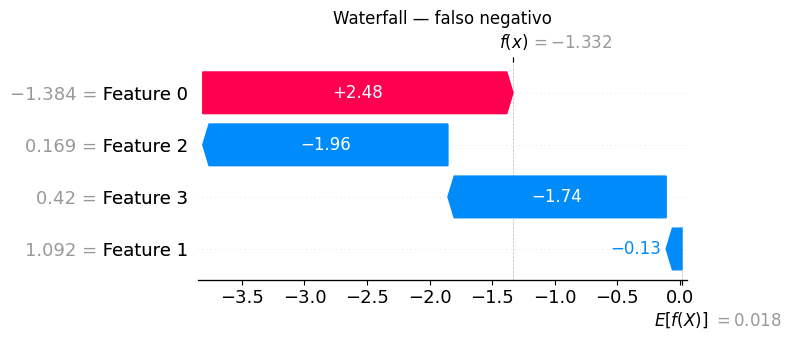

In [6]:
explainer_single = shap.TreeExplainer(modelo)
shap_single = explainer_single(asteroide.values.reshape(1,-1))

shap.plots.waterfall(shap_single[0], show=False)
plt.title('Waterfall — falso negativo')
plt.tight_layout()
plt.show()

### Conclusión del análisis

Este falso negativo ilustra la limitación principal del modelo:
cuando un asteroide grande pasa a distancia y velocidad normales,
las señales de velocity y miss_distance anulan la señal de tamaño.

El modelo necesitaría features orbitales más ricas (excentricidad,
inclinación, semieje mayor) para distinguir estos casos correctamente.
Con las 4 features disponibles, este tipo de error es estructural,
no se resuelve solo con más datos del mismo tipo.

## 5. Ajuste del umbral de decisión

Por defecto el modelo dice "peligroso" cuando la probabilidad supera 0.50.
Bajando el umbral priorizamos recall, detectar más peligrosos reales
a costa de más falsas alarmas.

In [ ]:
# Probabilidades en lugar de clases
y_proba = modelo.predict_proba(X_test)[:, 1]

print("Comparación de umbrales:\n")

for umbral in [0.50, 0.40, 0.30, 0.20]:
    y_pred_umbral = (y_proba >= umbral).astype(int)
    reporte = classification_report(y_test, y_pred_umbral,
                                   target_names=['No peligroso', 'Peligroso'],
                                   output_dict=True)
    print(f"Umbral {umbral}:")
    print(f"  Precision: {reporte['Peligroso']['precision']:.3f}")
    print(f"  Recall:    {reporte['Peligroso']['recall']:.3f}")
    print(f"  F1:        {reporte['Peligroso']['f1-score']:.3f}")
    print()

Comparación de umbrales:

Umbral 0.5:
  Precision: 0.405
  Recall:    0.758
  F1:        0.528

Umbral 0.4:
  Precision: 0.380
  Recall:    0.790
  F1:        0.513

Umbral 0.3:
  Precision: 0.366
  Recall:    0.837
  F1:        0.509

Umbral 0.2:
  Precision: 0.352
  Recall:    0.901
  F1:        0.507



### Umbral seleccionado: 0.20

En el contexto de detección de asteroides peligrosos, un falso negativo
(no detectar un asteroide peligroso) tiene consecuencias potencialmente
catastróficas. Un falso positivo (falsa alarma) tiene un costo operativo
manejable.

Por eso priorizamos recall sobre precision, seleccionando umbral 0.20:
- Recall: 0.901 → detecta 9 de cada 10 asteroides peligrosos reales
- Precision: 0.352 → de cada 10 alertas, 3.5 son realmente peligrosos

Esta es una decisión de negocio, no técnica.

In [ ]:
joblib.dump({'modelo': modelo, 'umbral': 0.20}, '../data/xgboost_final.pkl')
print("Modelo y umbral guardados")

Modelo y umbral guardados
